Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt
import seaborn as sns

Cell 2 — Load Data

In [2]:
df = pd.read_csv("hotspot_clustered.csv")

print(df.shape)
df.head()

(240654, 34)


,id,latitude,longitude,location,vehicle_number,vehicle_type,description,violation_type,offence_code,created_datetime,...,violations_list,num_violations,max_severity,vehicle_weight,junction_weight,hour,day_of_week,month,is_weekend,cluster_id
0,FKID000000,12.925557,77.618665,"18th Main Road, Block 2, Koramangala, Bengalur...",FKN00GL0000,CAR,NaN,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]","[112,104]",2023-11-20 00:28:46,...,"['WRONG PARKING', 'PARKING NEAR ROAD CROSSING']",2,6,1.5,1.000000,0.0,Monday,11.0,0,0.0
1,FKID000001,12.905463,77.700778,"Sarjapura Main Road, The Grove, Janatha Colony...",FKN00GL0001,CAR,NaN,"[""NO PARKING""]",[113],2023-11-24 22:46:46,...,['NO PARKING'],1,1,1.5,1.000000,22.0,Friday,11.0,0,-1.0
2,FKID000002,12.925449,77.618504,"Koramangala 2nd Block, Kormangala West, Bengal...",FKN00GL0002,CAR,NaN,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]","[112,107]",2023-11-20 00:27:46,...,"['WRONG PARKING', 'PARKING IN A MAIN ROAD']",2,5,1.5,1.000000,0.0,Monday,11.0,0,0.0
3,FKID000003,12.956521,77.518618,"6th Cross Road, Manasa Layout, Nagarbhavi, Ben...",FKN00GL0003,SCOOTER,NaN,"[""NO PARKING""]",[113],2023-11-16 06:47:46,...,['NO PARKING'],1,1,1.0,1.000000,6.0,Thursday,11.0,0,1.0
4,FKID000004,12.977767,77.580545,"Kalidasa Road, Gandhinagar, Nehru Nagar, Benga...",FKN00GL0004,TANKER,NaN,"[""NO PARKING""]",[113],2023-11-22 04:56:46,...,['NO PARKING'],1,1,4.0,0.074066,4.0,Wednesday,11.0,0,2.0


Cell 3 — Datetime

In [3]:
df["created_datetime"] = pd.to_datetime(
    df["created_datetime"]
)

df["year_month"] = (
    df["created_datetime"]
    .dt.to_period("M")
)

monthly_counts_global = (
    df.groupby("year_month")
    .size()
    .sort_index()
)

print(monthly_counts_global)

year_month
2023-11    33161
2023-12    46845
2024-01    44426
2024-02    48227
2024-03    52908
2024-04    15082
Freq: M, dtype: int64


Cell 4 — Monthly Violation Counts Per Cluster

In [4]:
monthly_counts = (
    df[df["cluster_id"] != -1]
    .groupby(
        ["cluster_id", "year_month"]
    )
    .size()
    .reset_index(name="violations")
)

monthly_counts.head()

,cluster_id,year_month,violations
0,0.0,2023-11,3
1,0.0,2023-12,87
2,0.0,2024-01,110
3,0.0,2024-02,153
4,0.0,2024-03,67


Cell 5 — Create Pivot Table  Rows: cluster, Columns: month, Values: violation

In [5]:
monthly_pivot = (
    monthly_counts
    .pivot(
        index="cluster_id",
        columns="year_month",
        values="violations"
    )
    .fillna(0)
)

monthly_pivot.head()

year_month,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04
cluster_id,,,,,,
0.0,3.0,87.0,110.0,153.0,67.0,7.0
1.0,49.0,70.0,97.0,44.0,129.0,38.0
2.0,6898.0,9716.0,9031.0,8960.0,10334.0,3319.0
3.0,3512.0,2488.0,3968.0,3141.0,4814.0,1322.0
4.0,222.0,234.0,285.0,290.0,270.0,21.0


Cell 6 — Verify Shape

In [6]:
print(monthly_pivot.shape)

(506, 6)


Cell 7 — Trajectory Slopes

In [7]:
slopes = []

for cluster_id, row in monthly_pivot.iterrows():

    y = row.values
    active_months = np.count_nonzero(y)

    if active_months < 2:
        slopes.append(
            [cluster_id, np.nan, np.nan]
        )
        continue

    X = np.arange(len(y)).reshape(-1,1)

    model = LinearRegression()
    model.fit(X, y)

    pred = model.predict(X)
    r2 = r2_score(y, pred)

    slopes.append(
        [cluster_id, model.coef_[0], r2]
    )

trajectory_df = pd.DataFrame(
    slopes,
    columns=["cluster_id", "slope", "r2"]
)

trajectory_df.head()

,cluster_id,slope,r2
0,0.0,0.085714,0.000007
1,1.0,1.971429,0.010723
2,2.0,-460.342857,0.110729
3,3.0,-137.114286,0.044890
4,4.0,-25.485714,0.221032


Cell 8 — Visualize Slope Distribution

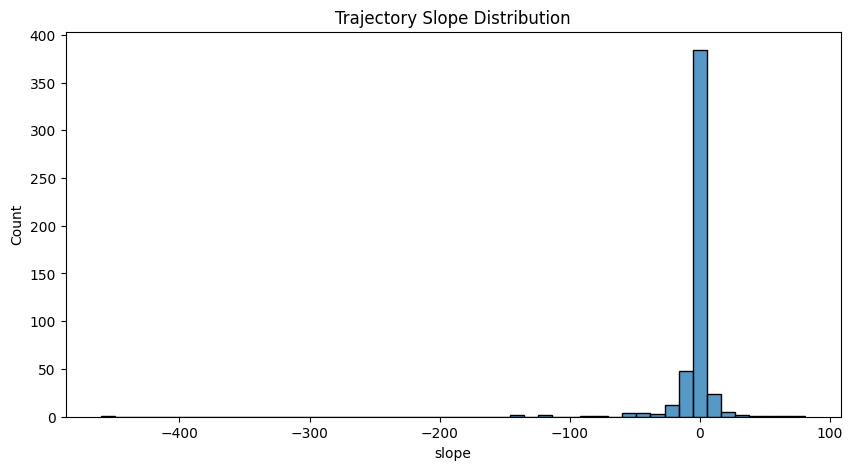

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    trajectory_df["slope"],
    bins=50
)

plt.title("Trajectory Slope Distribution")
plt.show()

Cell 9 — Data Driven Thresholds

In [9]:
valid_slopes = trajectory_df["slope"].dropna()

declining_threshold = (
    valid_slopes
    .quantile(0.25)
)

escalating_threshold = (
    valid_slopes
    .quantile(0.75)
)

print("Declining:", declining_threshold)
print("Escalating:", escalating_threshold)

Declining: -3.1142857142857143
Escalating: 1.0857142857142856


Cell 10 — Assign Labels

In [10]:
def classify_slope(x):

    if pd.isna(x):
        return "Insufficient History"

    if x >= escalating_threshold:
        return "Escalating"

    elif x <= declining_threshold:
        return "Declining"

    else:
        return "Stable"

trajectory_df["trajectory"] = (
    trajectory_df["slope"]
    .apply(classify_slope)
)

trajectory_df.head()

,cluster_id,slope,r2,trajectory
0,0.0,0.085714,0.000007,Stable
1,1.0,1.971429,0.010723,Escalating
2,2.0,-460.342857,0.110729,Declining
3,3.0,-137.114286,0.044890,Declining
4,4.0,-25.485714,0.221032,Declining


Cell 11 — Check Distribution

In [11]:
trajectory_df["trajectory"].value_counts()

trajectory
Stable                  247
Escalating              125
Declining               125
Insufficient History      9
Name: count, dtype: int64

Cell 12 — Top Escalating Hotspots

In [12]:
trajectory_df.sort_values(
    "slope",
    ascending=False
)[
    [
        "cluster_id",
        "slope",
        "r2",
        "trajectory"
    ]
].head(20)

,cluster_id,slope,r2,trajectory
56,56.0,81.028571,0.126356,Escalating
6,6.0,62.285714,0.179653,Escalating
31,31.0,53.914286,0.057540,Escalating
54,54.0,42.342857,0.775036,Escalating
110,110.0,34.257143,0.325084,Escalating
295,295.0,28.971429,0.600037,Escalating
50,50.0,25.428571,0.193301,Escalating
71,71.0,17.942857,0.088120,Escalating
187,187.0,17.457143,0.262344,Escalating
23,23.0,16.828571,0.034651,Escalating


Cell 13 — Anomaly Detection

In [13]:
cluster_month_stats = (
    monthly_pivot
    .agg(
        ["mean", "std"],
        axis=1
    )
)

cluster_month_stats.head()

,mean,std
cluster_id,,
0.0,71.166667,58.714280
1.0,71.166667,35.616944
2.0,8043.000000,2588.120708
3.0,3207.500000,1210.713467
4.0,220.333333,101.415318


Cell 14 — Current Month

In [14]:
print(monthly_counts_global)

latest_month = pd.Period("2024-03", freq="M")

print(latest_month)

year_month
2023-11    33161
2023-12    46845
2024-01    44426
2024-02    48227
2024-03    52908
2024-04    15082
Freq: M, dtype: int64
2024-03


Cell 15 — Current Month Count

In [15]:
cluster_month_stats["current_month"] = (
    monthly_pivot[latest_month]
)

Cell 16 — Z-score

In [16]:
def compute_z(row):

    if pd.isna(row["std"]):
        return np.nan

    if row["std"] == 0:
        return np.nan

    if row["mean"] == 0:
        return np.nan

    return (
        row["current_month"]
        - row["mean"]
    ) / row["std"]

cluster_month_stats["z_score"] = (
    cluster_month_stats
    .apply(compute_z, axis=1)
)

Cell 17 — Anomaly Labels

In [17]:
def anomaly_label(z):

    if pd.isna(z):
        return "Insufficient History"

    elif z > 1.5:
        return "Abnormal Surge"

    else:
        return "Normal"

cluster_month_stats["anomaly_status"] = (
    cluster_month_stats["z_score"]
    .apply(anomaly_label)
)

Cell 18 — Watchlist

In [18]:
watchlist = (
    cluster_month_stats[
        cluster_month_stats[
            "anomaly_status"
        ] == "Abnormal Surge"
    ]
    .sort_values(
        "z_score",
        ascending=False
    )
)

watchlist.head(20)

,mean,std,current_month,z_score,anomaly_status
cluster_id,,,,,
478.0,4.333333,10.614456,26.0,2.041241,Abnormal Surge
475.0,3.333333,8.164966,20.0,2.041241,Abnormal Surge
229.0,14.000000,31.868480,79.0,2.039633,Abnormal Surge
505.0,4.166667,9.239408,23.0,2.038370,Abnormal Surge
122.0,9.166667,19.083151,48.0,2.034954,Abnormal Surge
235.0,4.666667,9.500877,24.0,2.034900,Abnormal Surge
341.0,5.666667,10.984838,28.0,2.033105,Abnormal Surge
380.0,6.333333,12.722683,32.0,2.017394,Abnormal Surge
460.0,3.333333,5.785038,15.0,2.016697,Abnormal Surge


Cell 19 — Save Outputs

In [19]:
trajectory_df.to_csv(
    "trajectory_analysis.csv",
    index=False
)

cluster_month_stats.to_csv(
    "anomaly_analysis.csv"
)

print("Saved")

Saved


In [20]:
monthly_counts_global

year_month
2023-11    33161
2023-12    46845
2024-01    44426
2024-02    48227
2024-03    52908
2024-04    15082
Freq: M, dtype: int64